# Predictive Maintenance for Rolling-Element Bearings
## 01 — Exploratory Data Analysis

This notebook performs the first EDA pass on the FEMTO/PRONOSTIA bearing dataset.

### Goals

1. Register and validate the training, validation, and test archive paths.
2. Inventory the **training and validation** archives.
3. Validate filenames, schemas, delimiters, row counts, and missing values.
4. Compare bearing run lengths.
5. Visualize vibration signals at the beginning, middle, and end of a training run.
6. Extract time-domain and frequency-domain features.
7. Create Remaining Useful Life (RUL) labels for run-to-failure training bearings.
8. Identify data-quality and leakage risks before modeling.

> **Test-set safeguard:** `Test_set.zip` is registered by this notebook but intentionally excluded from EDA, feature selection, preprocessing decisions, and hyperparameter tuning. It should be opened only for the final locked-model evaluation.

The notebook reads CSV files directly from ZIP archives, so the full datasets do not need to be extracted.


In [ ]:
from pathlib import Path
from collections import defaultdict
import io
import os
import re
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


def resolve_project_root() -> Path:
    """Resolve the repository root when launched from root or notebooks/."""
    configured_root = os.getenv("MLOPS_BEARING_PROJECT_ROOT")

    if configured_root:
        return Path(configured_root).expanduser().resolve()

    current_dir = Path.cwd().resolve()

    if current_dir.name == "notebooks":
        return current_dir.parent

    if (current_dir / "data").exists() or (current_dir / "notebooks").exists():
        return current_dir

    # Useful when a notebook server starts one directory above the repository.
    candidate = current_dir / "mlops_bearing_project"
    if candidate.exists():
        return candidate

    return current_dir


PROJECT_ROOT = resolve_project_root()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda"

TRAIN_ZIP = RAW_DATA_DIR / "Training_set.zip"
VALIDATION_ZIP = RAW_DATA_DIR / "Validation_Set.zip"
TEST_ZIP = RAW_DATA_DIR / "Test_set.zip"

ARCHIVE_PATHS = {
    "train": TRAIN_ZIP,
    "validation": VALIDATION_ZIP,
    "test": TEST_ZIP,
}

# Training and validation are required to run this EDA notebook.
required_for_eda = {
    "train": TRAIN_ZIP,
    "validation": VALIDATION_ZIP,
}
missing_required = [
    str(path)
    for path in required_for_eda.values()
    if not path.exists()
]

if missing_required:
    missing_text = "\n".join(f"- {path}" for path in missing_required)
    raise FileNotFoundError(
        "Required EDA archives were not found:\n"
        f"{missing_text}\n\n"
        "Place the ZIP files under <project>/data/raw/. "
        "Do not extract them."
    )

archive_status = pd.DataFrame(
    [
        {
            "split": split,
            "path": str(path),
            "exists": path.exists(),
            "size_mb": (
                round(path.stat().st_size / (1024 ** 2), 2)
                if path.exists()
                else np.nan
            ),
            "eda_usage": (
                "EDA and model development"
                if split == "train"
                else "Pipeline validation"
                if split == "validation"
                else "Final locked-model evaluation only"
            ),
        }
        for split, path in ARCHIVE_PATHS.items()
    ]
)

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Raw data directory:", RAW_DATA_DIR)
print("EDA artifact directory:", ARTIFACT_DIR)

if not TEST_ZIP.exists():
    print(
        "\nWarning: Test_set.zip is not present yet. "
        "EDA can continue, but add it to data/raw/ before final evaluation."
    )

archive_status


Project root: /Users/sanketmayekar/AnuradhaM/MLOPS/MLOps-RUL
Raw data directory: /Users/sanketmayekar/AnuradhaM/MLOPS/MLOps-RUL/data/raw
EDA artifact directory: /Users/sanketmayekar/AnuradhaM/MLOPS/MLOps-RUL/artifacts/eda


,split,path,exists,size_mb,eda_usage
0,train,/Users/sanketmayekar/AnuradhaM/MLOPS/MLOps-RUL...,True,133.92,EDA and model development
1,validation,/Users/sanketmayekar/AnuradhaM/MLOPS/MLOps-RUL...,True,302.07,Pipeline validation
2,test,/Users/sanketmayekar/AnuradhaM/MLOPS/MLOps-RUL...,True,673.10,Final locked-model evaluation only


## 1. Dataset assumptions

Each acceleration file is expected to contain six columns:

- hour
- minute
- second
- sub-second timestamp
- horizontal acceleration
- vertical acceleration

A normal acceleration snapshot contains 2,560 signal samples. Snapshot files are generally recorded every 10 seconds.

Some files use commas, while others use semicolons. The parser below detects the separator automatically.

In [2]:
ACC_COLUMNS = [
    "hour",
    "minute",
    "second",
    "subsecond",
    "acc_horizontal",
    "acc_vertical",
]

TEMP_COLUMNS = [
    "hour",
    "minute",
    "second",
    "subsecond",
    "temperature",
]


def detect_separator(text: str) -> str:
    first_line = text.splitlines()[0]
    return ";" if first_line.count(";") > first_line.count(",") else ","


def read_csv_from_zip(
    archive: zipfile.ZipFile,
    member_name: str,
    columns: list[str],
) -> pd.DataFrame:
    raw = archive.read(member_name)
    text = raw.decode("utf-8", errors="replace")
    separator = detect_separator(text)

    frame = pd.read_csv(
        io.StringIO(text),
        sep=separator,
        header=None,
        names=columns,
    )

    for column in columns:
        frame[column] = pd.to_numeric(frame[column], errors="coerce")

    return frame


def bearing_folder(member_name: str) -> str:
    return "/".join(member_name.split("/")[:-1])


def numeric_file_index(member_name: str) -> int:
    match = re.search(r"_(\d+)\.csv$", member_name)
    if not match:
        raise ValueError(f"Unexpected filename: {member_name}")
    return int(match.group(1))

## 2. Archive inventory

The inventory below reads only the **training** and **validation** archives.

`Test_set.zip` is deliberately excluded so the final holdout does not influence EDA or modeling decisions.


In [3]:
def build_archive_inventory(
    zip_path: Path,
    split: str,
) -> pd.DataFrame:
    records = []

    with zipfile.ZipFile(zip_path) as archive:
        grouped = defaultdict(list)

        for info in archive.infolist():
            if info.is_dir() or not info.filename.lower().endswith(".csv"):
                continue
            grouped[bearing_folder(info.filename)].append(info.filename)

        for folder, members in sorted(grouped.items()):
            acceleration_files = sorted(
                [
                    name
                    for name in members
                    if os.path.basename(name).startswith("acc_")
                ],
                key=numeric_file_index,
            )
            temperature_files = sorted(
                [
                    name
                    for name in members
                    if os.path.basename(name).startswith("temp_")
                ],
                key=numeric_file_index,
            )

            if not acceleration_files:
                continue

            acceleration_numbers = [
                numeric_file_index(name)
                for name in acceleration_files
            ]
            number_gaps = (
                max(acceleration_numbers)
                - min(acceleration_numbers)
                + 1
                - len(acceleration_numbers)
            )

            first_acc = read_csv_from_zip(
                archive,
                acceleration_files[0],
                ACC_COLUMNS,
            )
            separator = detect_separator(
                archive.read(acceleration_files[0]).decode(
                    "utf-8",
                    errors="replace",
                )
            )

            bearing = os.path.basename(folder)
            condition_match = re.search(r"Bearing(\d+)_", bearing)
            operating_condition = (
                int(condition_match.group(1))
                if condition_match
                else np.nan
            )

            records.append(
                {
                    "split": split,
                    "bearing": bearing,
                    "operating_condition": operating_condition,
                    "acceleration_files": len(acceleration_files),
                    "temperature_files": len(temperature_files),
                    "estimated_duration_seconds": max(
                        len(acceleration_files) - 1,
                        0,
                    )
                    * 10,
                    "estimated_duration_hours": max(
                        len(acceleration_files) - 1,
                        0,
                    )
                    * 10
                    / 3600,
                    "acceleration_rows_first_file": len(first_acc),
                    "first_file_missing_values": int(
                        first_acc.isna().sum().sum()
                    ),
                    "separator": (
                        "semicolon"
                        if separator == ";"
                        else "comma"
                    ),
                    "filename_number_gaps": number_gaps,
                }
            )

    return pd.DataFrame(records)


# Test_set.zip is intentionally not included here.
EDA_ARCHIVES = {
    "train": TRAIN_ZIP,
    "validation": VALIDATION_ZIP,
}

inventory_frames = [
    build_archive_inventory(path, split)
    for split, path in EDA_ARCHIVES.items()
]

inventory = (
    pd.concat(inventory_frames, ignore_index=True)
    .sort_values(
        ["split", "operating_condition", "bearing"]
    )
    .reset_index(drop=True)
)

inventory


,split,bearing,operating_condition,acceleration_files,temperature_files,estimated_duration_seconds,estimated_duration_hours,acceleration_rows_first_file,first_file_missing_values,separator,filename_number_gaps
0,train,Bearing1_1,1,2803,466,28020,7.783333,2560,0,comma,0
1,train,Bearing1_2,1,871,144,8700,2.416667,2560,0,comma,0
2,train,Bearing2_1,2,911,151,9100,2.527778,2560,0,comma,0
3,train,Bearing2_2,2,797,0,7960,2.211111,2560,0,comma,0
4,train,Bearing3_1,3,515,89,5140,1.427778,2560,0,comma,0
5,train,Bearing3_2,3,1637,0,16360,4.544444,2560,0,comma,0
6,validation,Bearing1_3,1,2375,0,23740,6.594444,2560,0,comma,0
7,validation,Bearing1_4,1,1428,237,14270,3.963889,2560,0,semicolon,0
8,validation,Bearing1_5,1,2463,410,24620,6.838889,2560,0,comma,0
9,validation,Bearing1_6,1,2448,408,24470,6.797222,2560,0,comma,0


In [4]:
inventory_summary = (
    inventory.groupby("split")
    .agg(
        bearings=("bearing", "count"),
        acceleration_files=("acceleration_files", "sum"),
        temperature_files=("temperature_files", "sum"),
        total_estimated_hours=("estimated_duration_hours", "sum"),
    )
    .reset_index()
)

inventory_summary

,split,bearings,acceleration_files,temperature_files,total_estimated_hours
0,train,6,7534,850,20.911111
1,validation,11,17355,2168,48.177778


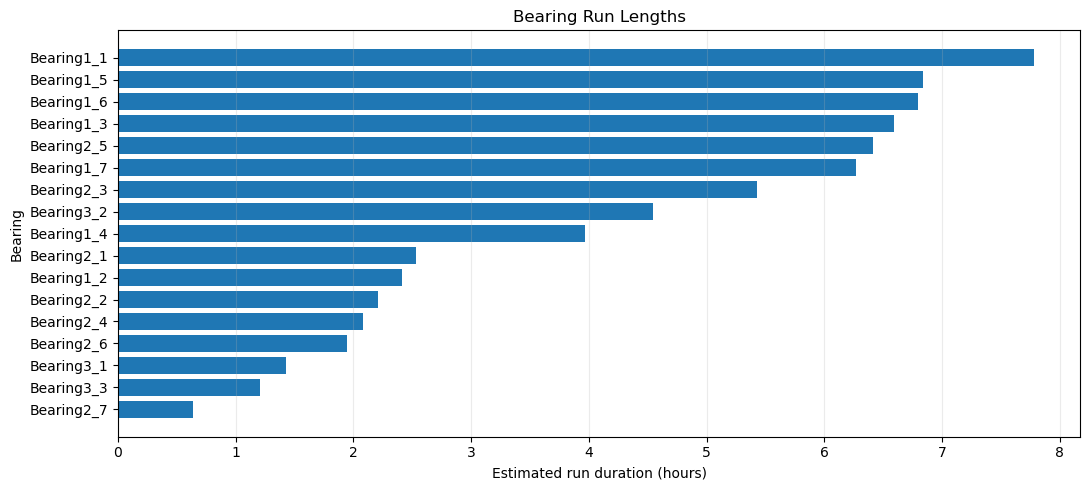

In [5]:
fig, ax = plt.subplots(figsize=(11, 5))
plot_data = inventory.sort_values("estimated_duration_hours")
ax.barh(
    plot_data["bearing"],
    plot_data["estimated_duration_hours"],
)
ax.set_xlabel("Estimated run duration (hours)")
ax.set_ylabel("Bearing")
ax.set_title("Bearing Run Lengths")
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

## 3. Structural data-quality checks

These checks look for:

- missing acceleration files in a sequence
- unexpected row counts
- missing or nonnumeric values
- inconsistent separators
- unavailable temperature data

Temperature is treated as optional because it is not consistently available across all bearings.

In [6]:
quality_flags = inventory.assign(
    unexpected_acceleration_rows=(
        inventory["acceleration_rows_first_file"] != 2560
    ),
    has_missing_values=(
        inventory["first_file_missing_values"] > 0
    ),
    missing_temperature=(
        inventory["temperature_files"] == 0
    ),
    has_filename_gaps=(
        inventory["filename_number_gaps"] > 0
    ),
)

quality_flags[
    [
        "split",
        "bearing",
        "separator",
        "acceleration_rows_first_file",
        "has_missing_values",
        "missing_temperature",
        "has_filename_gaps",
    ]
]

,split,bearing,separator,acceleration_rows_first_file,has_missing_values,missing_temperature,has_filename_gaps
0,train,Bearing1_1,comma,2560,False,False,False
1,train,Bearing1_2,comma,2560,False,False,False
2,train,Bearing2_1,comma,2560,False,False,False
3,train,Bearing2_2,comma,2560,False,True,False
4,train,Bearing3_1,comma,2560,False,False,False
5,train,Bearing3_2,comma,2560,False,True,False
6,validation,Bearing1_3,comma,2560,False,True,False
7,validation,Bearing1_4,semicolon,2560,False,False,False
8,validation,Bearing1_5,comma,2560,False,False,False
9,validation,Bearing1_6,comma,2560,False,False,False


## 4. Read a bearing's acceleration files

In [7]:
def list_bearing_acceleration_files(
    archive: zipfile.ZipFile,
    bearing: str,
) -> list[str]:
    files = [
        name
        for name in archive.namelist()
        if f"/{bearing}/acc_" in name
        and name.lower().endswith(".csv")
    ]
    return sorted(files, key=numeric_file_index)


def load_bearing_snapshot(
    zip_path: Path,
    bearing: str,
    position: str = "start",
) -> tuple[pd.DataFrame, str]:
    with zipfile.ZipFile(zip_path) as archive:
        files = list_bearing_acceleration_files(
            archive,
            bearing,
        )

        if not files:
            raise ValueError(
                f"No acceleration files found for {bearing}"
            )

        positions = {
            "start": 0,
            "middle": len(files) // 2,
            "end": len(files) - 1,
        }

        if position not in positions:
            raise ValueError(
                "position must be start, middle, or end"
            )

        filename = files[positions[position]]
        frame = read_csv_from_zip(
            archive,
            filename,
            ACC_COLUMNS,
        )
        return frame, filename

In [8]:
SELECTED_BEARING = "Bearing1_1"
SELECTED_ARCHIVE = TRAIN_ZIP

start_signal, start_file = load_bearing_snapshot(
    SELECTED_ARCHIVE,
    SELECTED_BEARING,
    "start",
)
middle_signal, middle_file = load_bearing_snapshot(
    SELECTED_ARCHIVE,
    SELECTED_BEARING,
    "middle",
)
end_signal, end_file = load_bearing_snapshot(
    SELECTED_ARCHIVE,
    SELECTED_BEARING,
    "end",
)

print(start_file, start_signal.shape)
print(middle_file, middle_signal.shape)
print(end_file, end_signal.shape)

start_signal.head()

Learning_set/Bearing1_1/acc_00001.csv (2560, 6)
Learning_set/Bearing1_1/acc_01402.csv (2560, 6)
Learning_set/Bearing1_1/acc_02803.csv (2560, 6)


,hour,minute,second,subsecond,acc_horizontal,acc_vertical
0,9,39,39,65664.0,0.552,-0.146
1,9,39,39,65703.0,0.501,-0.480
2,9,39,39,65742.0,0.138,0.435
3,9,39,39,65781.0,-0.423,0.240
4,9,39,39,65820.0,-0.802,0.020


## 5. Waveform comparison: start, middle, and end

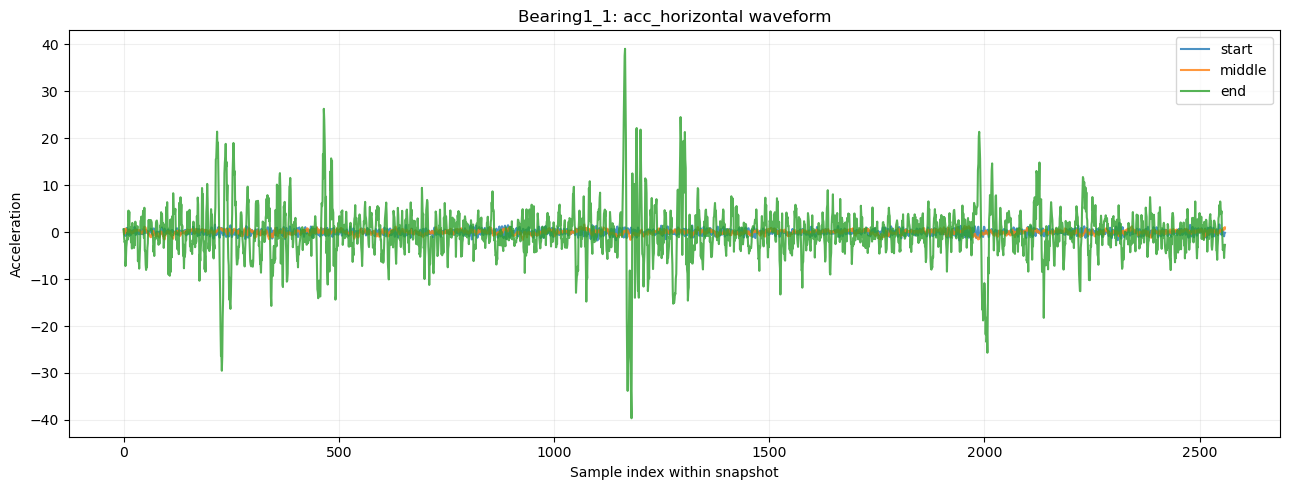

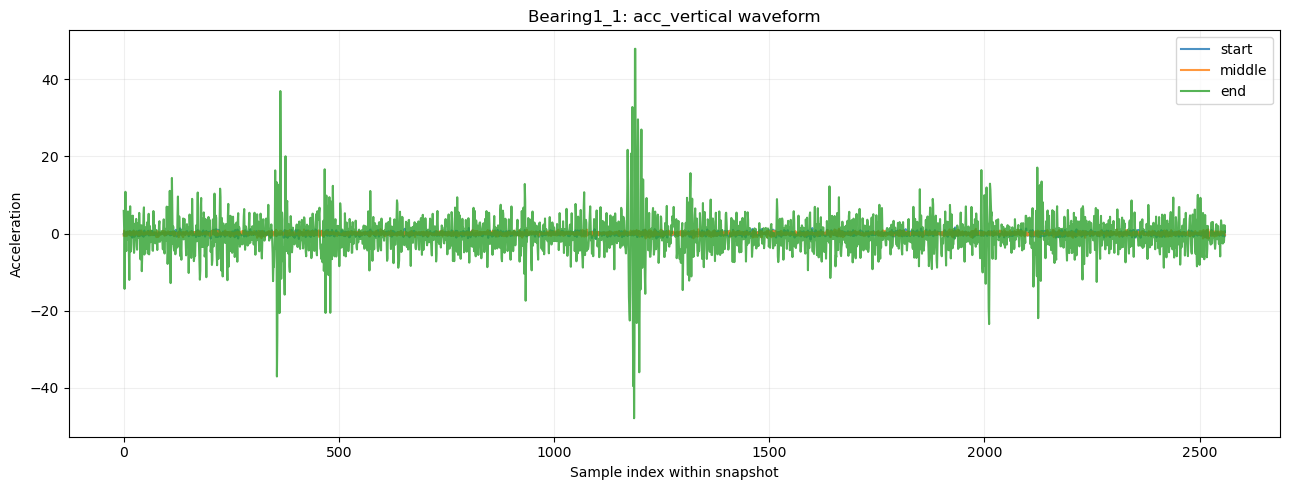

In [9]:
def plot_waveform_comparison(
    signals: dict[str, pd.DataFrame],
    channel: str,
    max_points: int = 2560,
) -> None:
    fig, ax = plt.subplots(figsize=(13, 5))

    for stage, frame in signals.items():
        values = frame[channel].iloc[:max_points].to_numpy()
        ax.plot(
            values,
            label=stage,
            alpha=0.8,
        )

    ax.set_title(
        f"{SELECTED_BEARING}: {channel} waveform"
    )
    ax.set_xlabel("Sample index within snapshot")
    ax.set_ylabel("Acceleration")
    ax.legend()
    ax.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()


signals = {
    "start": start_signal,
    "middle": middle_signal,
    "end": end_signal,
}

plot_waveform_comparison(signals, "acc_horizontal")
plot_waveform_comparison(signals, "acc_vertical")

## 6. Feature extraction

The first baseline feature set includes:

### Time-domain
- mean
- standard deviation
- RMS
- minimum and maximum
- peak-to-peak amplitude
- absolute peak
- skewness
- kurtosis
- crest factor

### Frequency-domain
- dominant frequency
- spectral centroid
- energy in configurable frequency bands

The sampling frequency is 25.6 kHz, and each vibration snapshot contains 2,560 samples.

In [10]:
SAMPLING_FREQUENCY_HZ = 25_600
SNAPSHOT_INTERVAL_SECONDS = 10

FREQUENCY_BANDS_HZ = [
    (0, 1_000),
    (1_000, 3_000),
    (3_000, 6_000),
    (6_000, 10_000),
    (10_000, 12_800),
]


def time_domain_features(
    values: np.ndarray,
    prefix: str,
) -> dict[str, float]:
    values = np.asarray(values, dtype=float)
    rms = float(np.sqrt(np.mean(values ** 2)))
    absolute_peak = float(np.max(np.abs(values)))

    return {
        f"{prefix}_mean": float(np.mean(values)),
        f"{prefix}_std": float(np.std(values, ddof=1)),
        f"{prefix}_rms": rms,
        f"{prefix}_min": float(np.min(values)),
        f"{prefix}_max": float(np.max(values)),
        f"{prefix}_peak_to_peak": float(np.ptp(values)),
        f"{prefix}_absolute_peak": absolute_peak,
        f"{prefix}_skewness": float(
            skew(values, bias=False)
        ),
        f"{prefix}_kurtosis": float(
            kurtosis(
                values,
                fisher=False,
                bias=False,
            )
        ),
        f"{prefix}_crest_factor": (
            absolute_peak / rms if rms > 0 else np.nan
        ),
    }


def frequency_domain_features(
    values: np.ndarray,
    prefix: str,
    sampling_frequency_hz: float = SAMPLING_FREQUENCY_HZ,
) -> dict[str, float]:
    values = np.asarray(values, dtype=float)
    centered = values - np.mean(values)

    frequencies = np.fft.rfftfreq(
        len(centered),
        d=1.0 / sampling_frequency_hz,
    )
    spectrum = np.abs(np.fft.rfft(centered))
    power = spectrum ** 2

    non_dc_power = power.copy()
    if len(non_dc_power):
        non_dc_power[0] = 0

    dominant_frequency = float(
        frequencies[int(np.argmax(non_dc_power))]
    )

    total_power = float(np.sum(non_dc_power))
    spectral_centroid = (
        float(
            np.sum(frequencies * non_dc_power)
            / total_power
        )
        if total_power > 0
        else np.nan
    )

    features = {
        f"{prefix}_dominant_frequency_hz": (
            dominant_frequency
        ),
        f"{prefix}_spectral_centroid_hz": (
            spectral_centroid
        ),
        f"{prefix}_total_spectral_energy": total_power,
    }

    for lower, upper in FREQUENCY_BANDS_HZ:
        mask = (
            (frequencies >= lower)
            & (frequencies < upper)
        )
        band_power = float(
            np.sum(non_dc_power[mask])
        )

        features[
            f"{prefix}_band_energy_{lower}_{upper}_hz"
        ] = band_power
        features[
            f"{prefix}_band_energy_ratio_{lower}_{upper}_hz"
        ] = (
            band_power / total_power
            if total_power > 0
            else np.nan
        )

    return features


def extract_snapshot_features(
    frame: pd.DataFrame,
) -> dict[str, float]:
    output = {}

    for channel, prefix in [
        ("acc_horizontal", "horizontal"),
        ("acc_vertical", "vertical"),
    ]:
        values = (
            frame[channel]
            .dropna()
            .to_numpy(dtype=float)
        )
        output.update(
            time_domain_features(
                values,
                prefix,
            )
        )
        output.update(
            frequency_domain_features(
                values,
                prefix,
            )
        )

    return output


pd.DataFrame(
    [
        {
            "stage": "start",
            **extract_snapshot_features(start_signal),
        },
        {
            "stage": "middle",
            **extract_snapshot_features(middle_signal),
        },
        {
            "stage": "end",
            **extract_snapshot_features(end_signal),
        },
    ]
)[
    [
        "stage",
        "horizontal_rms",
        "vertical_rms",
        "horizontal_kurtosis",
        "vertical_kurtosis",
        "horizontal_crest_factor",
        "vertical_crest_factor",
        "horizontal_dominant_frequency_hz",
        "vertical_dominant_frequency_hz",
    ]
]

,stage,horizontal_rms,vertical_rms,horizontal_kurtosis,vertical_kurtosis,horizontal_crest_factor,vertical_crest_factor,horizontal_dominant_frequency_hz,vertical_dominant_frequency_hz
0,start,0.561746,0.435801,2.870625,2.967198,3.578132,3.650745,3750.0,5820.0
1,middle,0.451714,0.380974,3.407677,3.083749,3.641687,3.433304,120.0,10010.0
2,end,5.607562,5.119619,11.038872,19.671445,7.071522,9.346203,2170.0,4030.0


## 7. Extract features across one complete bearing run

Start with one bearing to validate the pipeline before processing all files.

Set `FILE_STEP` to a value greater than 1 for faster exploratory sampling. For example, `FILE_STEP = 10` processes one snapshot every 100 seconds.

In [11]:
def extract_bearing_feature_table(
    zip_path: Path,
    bearing: str,
    file_step: int = 1,
) -> pd.DataFrame:
    records = []

    with zipfile.ZipFile(zip_path) as archive:
        all_files = list_bearing_acceleration_files(
            archive,
            bearing,
        )
        selected_files = all_files[::file_step]
        total_snapshots = len(all_files)

        for filename in selected_files:
            snapshot_number = numeric_file_index(
                filename
            )
            snapshot_index = snapshot_number - 1

            frame = read_csv_from_zip(
                archive,
                filename,
                ACC_COLUMNS,
            )
            features = extract_snapshot_features(
                frame
            )

            records.append(
                {
                    "bearing": bearing,
                    "file": os.path.basename(filename),
                    "snapshot_number": snapshot_number,
                    "elapsed_seconds": (
                        snapshot_index
                        * SNAPSHOT_INTERVAL_SECONDS
                    ),
                    "elapsed_hours": (
                        snapshot_index
                        * SNAPSHOT_INTERVAL_SECONDS
                        / 3600
                    ),
                    "rul_seconds": (
                        total_snapshots
                        - 1
                        - snapshot_index
                    )
                    * SNAPSHOT_INTERVAL_SECONDS,
                    "rul_hours": (
                        total_snapshots
                        - 1
                        - snapshot_index
                    )
                    * SNAPSHOT_INTERVAL_SECONDS
                    / 3600,
                    **features,
                }
            )

    return pd.DataFrame(records)


# Use 10 for a fast EDA run; change to 1 for every snapshot.
FILE_STEP = 10

bearing_features = extract_bearing_feature_table(
    TRAIN_ZIP,
    SELECTED_BEARING,
    file_step=FILE_STEP,
)

bearing_features.head()

,bearing,file,snapshot_number,elapsed_seconds,elapsed_hours,rul_seconds,rul_hours,horizontal_mean,horizontal_std,horizontal_rms,horizontal_min,horizontal_max,horizontal_peak_to_peak,horizontal_absolute_peak,horizontal_skewness,horizontal_kurtosis,horizontal_crest_factor,horizontal_dominant_frequency_hz,horizontal_spectral_centroid_hz,horizontal_total_spectral_energy,horizontal_band_energy_0_1000_hz,horizontal_band_energy_ratio_0_1000_hz,horizontal_band_energy_1000_3000_hz,horizontal_band_energy_ratio_1000_3000_hz,horizontal_band_energy_3000_6000_hz,horizontal_band_energy_ratio_3000_6000_hz,horizontal_band_energy_6000_10000_hz,horizontal_band_energy_ratio_6000_10000_hz,horizontal_band_energy_10000_12800_hz,horizontal_band_energy_ratio_10000_12800_hz,vertical_mean,vertical_std,vertical_rms,vertical_min,vertical_max,vertical_peak_to_peak,vertical_absolute_peak,vertical_skewness,vertical_kurtosis,vertical_crest_factor,vertical_dominant_frequency_hz,vertical_spectral_centroid_hz,vertical_total_spectral_energy,vertical_band_energy_0_1000_hz,vertical_band_energy_ratio_0_1000_hz,vertical_band_energy_1000_3000_hz,vertical_band_energy_ratio_1000_3000_hz,vertical_band_energy_3000_6000_hz,vertical_band_energy_ratio_3000_6000_hz,vertical_band_energy_6000_10000_hz,vertical_band_energy_ratio_6000_10000_hz,vertical_band_energy_10000_12800_hz,vertical_band_energy_ratio_10000_12800_hz
0,Bearing1_1,acc_00001.csv,1,0,0.000000,28020,7.783333,0.003465,0.561845,0.561746,-1.763,2.010,3.773,2.010,-0.004714,2.870625,3.578132,3750.0,3718.120812,1.034026e+06,37004.820293,0.035787,136490.351071,0.131999,814136.294711,0.787346,33409.889150,0.032310,12895.901713,0.012472,-0.001881,0.435883,0.435801,-1.569,1.591,3.160,1.591,0.002715,2.967198,3.650745,5820.0,6359.289741,622349.464594,7781.883403,0.012504,84744.547454,0.136169,229817.685842,0.369274,181896.099797,0.292273,118065.714494,0.189710
1,Bearing1_1,acc_00011.csv,11,100,0.027778,27920,7.755556,0.001051,0.541737,0.541632,-2.199,2.542,4.741,2.542,0.028576,3.403908,4.693220,3960.0,3846.140574,9.613567e+05,48650.675832,0.050606,115666.889604,0.120316,757896.876723,0.788362,23885.084233,0.024845,15137.485368,0.015746,0.001103,0.456277,0.456189,-1.970,1.548,3.518,1.970,-0.052071,3.074023,4.318384,5730.0,6512.770248,681938.295940,8100.570685,0.011879,58808.444803,0.086237,294387.293403,0.431692,212617.606721,0.311784,108000.301678,0.158373
2,Bearing1_1,acc_00021.csv,21,200,0.055556,27820,7.727778,0.002503,0.496206,0.496116,-2.008,1.791,3.799,2.008,-0.072437,3.129233,4.047442,3790.0,3776.783381,8.066052e+05,31917.986695,0.039571,132500.904570,0.164270,601793.071547,0.746081,22761.975510,0.028219,17423.077575,0.021601,0.007448,0.471950,0.471917,-1.533,1.723,3.256,1.723,0.003469,3.121654,3.651069,5520.0,6578.874538,729603.081268,6829.272017,0.009360,83920.880425,0.115023,272293.399006,0.373208,239498.309929,0.328258,127012.569267,0.174084
3,Bearing1_1,acc_00031.csv,31,300,0.083333,27720,7.700000,-0.004820,0.620430,0.620327,-2.080,1.860,3.940,2.080,-0.036305,2.877370,3.353068,3760.0,3699.029467,1.260892e+06,35816.258571,0.028405,217567.806874,0.172551,948968.279724,0.752616,35055.215613,0.027802,23412.915169,0.018569,0.000811,0.511465,0.511366,-1.854,1.677,3.531,1.854,-0.021358,2.909803,3.625585,10140.0,6641.013435,856864.250728,8546.619195,0.009974,96606.313905,0.112744,307708.963506,0.359111,299709.476899,0.349775,144292.877197,0.168396
4,Bearing1_1,acc_00041.csv,41,400,0.111111,27620,7.672222,0.002445,0.600479,0.600367,-2.225,2.418,4.643,2.418,0.047797,3.091648,4.027536,3570.0,3606.769915,1.181073e+06,35457.419988,0.030021,230884.178040,0.195487,854608.126221,0.723586,38462.992827,0.032566,21658.090867,0.018338,0.003010,0.490923,0.490837,-1.830,1.849,3.679,1.849,-0.044015,3.161850,3.767037,9940.0,6597.024567,789419.061988,7515.513309,0.009520,71827.786645,0.090988,298755.446929,0.378450,297069.420070,0.376314,114250.778753,0.144728


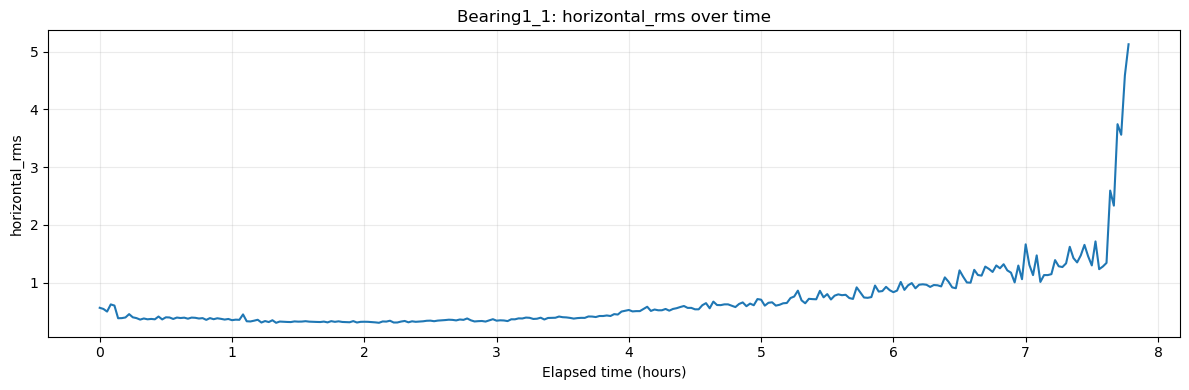

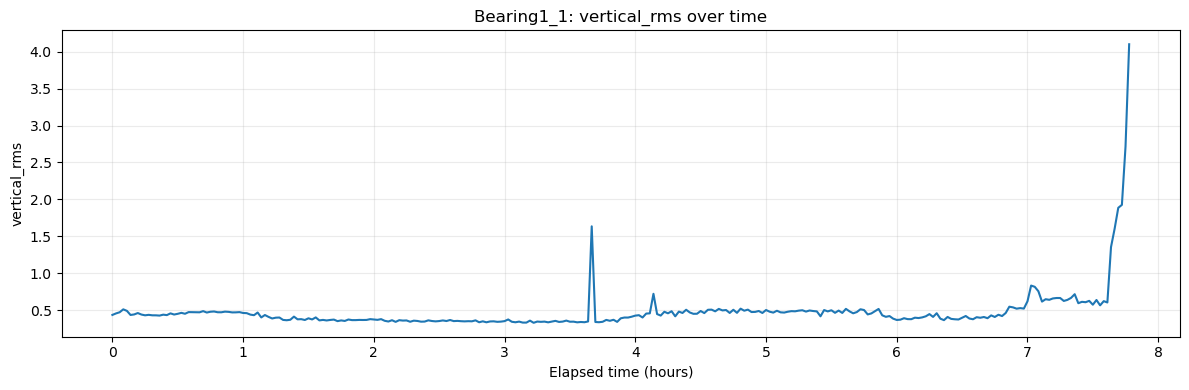

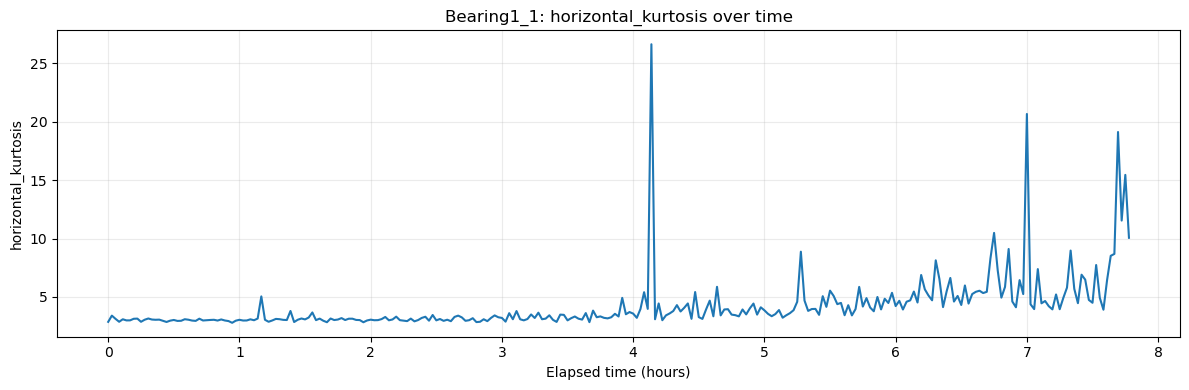

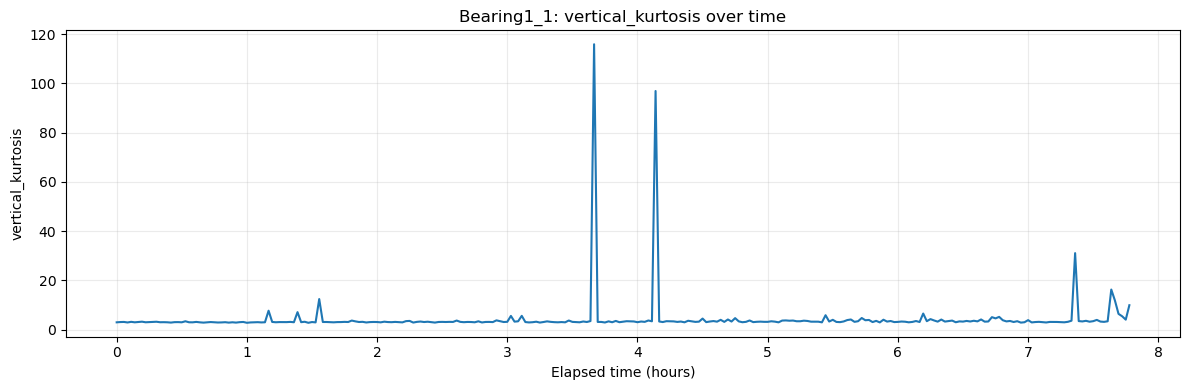

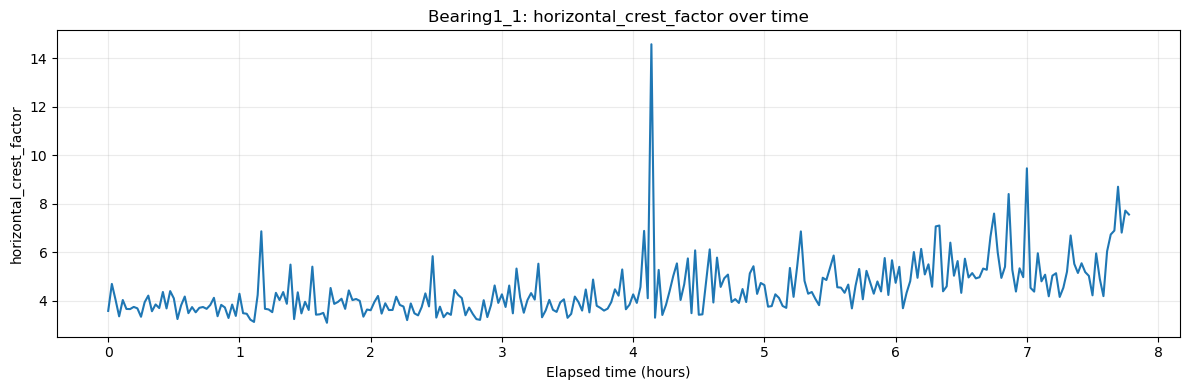

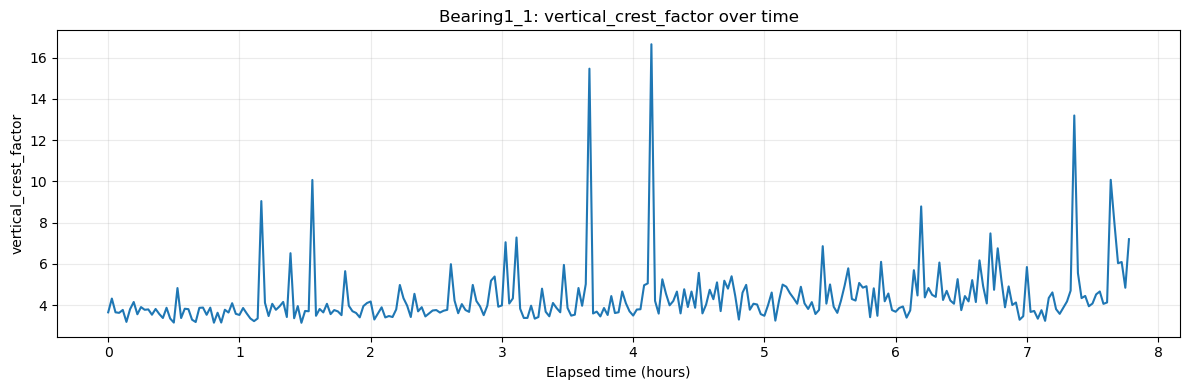

In [12]:
features_to_plot = [
    "horizontal_rms",
    "vertical_rms",
    "horizontal_kurtosis",
    "vertical_kurtosis",
    "horizontal_crest_factor",
    "vertical_crest_factor",
]

for feature in features_to_plot:
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(
        bearing_features["elapsed_hours"],
        bearing_features[feature],
    )
    ax.set_title(
        f"{SELECTED_BEARING}: {feature} over time"
    )
    ax.set_xlabel("Elapsed time (hours)")
    ax.set_ylabel(feature)
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Feature correlations and target relationship

Correlation is exploratory only. Bearing degradation is nonlinear, and neighboring snapshots from the same bearing are highly dependent.

In [13]:
numeric_columns = bearing_features.select_dtypes(
    include="number"
).columns

correlations_with_rul = (
    bearing_features[numeric_columns]
    .corr(numeric_only=True)["rul_hours"]
    .drop("rul_hours")
    .sort_values(
        key=np.abs,
        ascending=False,
    )
)

correlations_with_rul.head(20)

elapsed_hours                                -1.000000
snapshot_number                              -1.000000
elapsed_seconds                              -1.000000
rul_seconds                                   1.000000
horizontal_band_energy_ratio_6000_10000_hz    0.888989
horizontal_spectral_centroid_hz               0.869314
horizontal_band_energy_ratio_0_1000_hz       -0.835761
horizontal_band_energy_ratio_3000_6000_hz     0.793644
horizontal_std                               -0.681251
horizontal_rms                               -0.680672
horizontal_dominant_frequency_hz              0.602508
horizontal_max                               -0.594232
horizontal_absolute_peak                     -0.589009
horizontal_peak_to_peak                      -0.588844
horizontal_min                                0.578405
vertical_band_energy_ratio_3000_6000_hz       0.569919
horizontal_crest_factor                      -0.531026
horizontal_band_energy_0_1000_hz             -0.505166
horizontal

## 9. Export the feature table

Generated EDA features are written under `artifacts/eda/`. Raw ZIP archives remain unchanged under `data/raw/`.


In [14]:
csv_path = ARTIFACT_DIR / f"eda_features_{SELECTED_BEARING}.csv"

bearing_features.to_csv(
    csv_path,
    index=False,
)

print("Saved:", csv_path.resolve())


Saved: /Users/sanketmayekar/AnuradhaM/MLOPS/MLOps-RUL/artifacts/eda/eda_features_Bearing1_1.csv


## 10. EDA conclusions to document

After running the notebook, record:

1. Whether every acceleration snapshot has 2,560 rows and six numeric columns.
2. Which folders use semicolon-delimited files.
3. Which bearings contain temperature files.
4. Whether temperature values are credible and consistently available.
5. Run-length differences across bearings and operating conditions.
6. How RMS, kurtosis, crest factor, and spectral features change near failure.
7. Whether both accelerometer channels contribute useful information.
8. Whether smoothing or rolling-window features are needed.
9. Whether any features are dominated by rare spikes or sensor corruption.
10. The exact RUL-label definition used for training.

### Dataset usage policy

- `Training_set.zip`: EDA, feature engineering, model fitting, and bearing-level cross-validation.
- `Validation_Set.zip`: pipeline validation and model-selection checks.
- `Test_set.zip`: one-time final evaluation after the pipeline and model are frozen.
- Keep all three archives unchanged under `data/raw/`.
- Do not extract, rename, overwrite, or manually edit individual signal files.

### MLOps safeguards

- Do not randomly split snapshots across train and test sets.
- Split by complete bearing to prevent leakage.
- Fit scalers and preprocessing only on training bearings.
- Version raw archive references, feature code, generated feature tables, and the RUL-label definition.
- Log feature configuration and sampling frequency with each MLflow run.
- Keep `Test_set.zip` untouched until final evaluation.
